# MobileNetV3-Large para classificação de imagens CPRE / MIQR-CC

Este notebook treina e avalia uma **MobileNetV3-Large** com *transfer learning* para classificação multi-classe de imagens fluoroscópicas de CPRE nas 4 classes finais

In [1]:
# =========================
# 1. Imports e configuração
# =========================

import os
import json
import copy
import random
import warnings
from typing import Callable, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large

try:
    from torchvision.models import MobileNet_V3_Large_Weights
except Exception:
    MobileNet_V3_Large_Weights = None

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# -------------------------
# Paths do servidor
# -------------------------
DATA_ROOT = '/mounts/mecd-ap-g5/data'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'

NOTEBOOK_NAME = 'mobilenet_v3_large_miqr_cc'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# -------------------------
# Hiperparâmetros principais
# -------------------------
SEED = 42
IMG_SIZE = 224          # MobileNet foi pré-treinada em 224x224. Pode testar 256 ou 320 se tiver VRAM.
BATCH_SIZE = 16         # Reduza para 8/4 se der erro de memória.
NUM_WORKERS = 4
NUM_EPOCHS_HEAD = 5     # 1.ª fase: treina só a cabeça de classificação.
NUM_EPOCHS_FINETUNE = 25 # 2.ª fase: fine-tuning parcial/total.
PATIENCE = 8
LR_HEAD = 3e-4
LR_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
USE_CLAHE = False
GEOMETRY_MODE = 'pad_resize_if_rect'  # opções: 'direct_resize' ou 'pad_resize_if_rect'
FREEZE_BACKBONE_HEAD_PHASE = True
UNFREEZE_LAST_N_FEATURE_BLOCKS = 4     # fine-tuning parcial: desbloqueia os últimos blocos da feature extractor.
USE_WEIGHTED_SAMPLER = True
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0

# Normalização ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Reprodutibilidade
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM GB:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:', MODELS_DIR)

Device: cpu
RESULTS_DIR: /mounts/mecd-ap-g5/results/mobilenet_v3_large_miqr_cc
MODELS_DIR: /mounts/mecd-ap-g5/models/mobilenet_v3_large_miqr_cc


## 2. Leitura e preparação do dataset

A lógica abaixo segue o mesmo padrão do notebook de referência:

- usa `metadata.csv`;
- mantém apenas linhas com `Keep == keep`;
- exclui imagens sem label;
- junta `Benign Stricture` e `Malignant Stricture` na classe final `Stricture`;
- cria o caminho completo da imagem a partir de `processed_image_path`.

In [4]:
# =========================
# 2. Carregar metadata
# =========================

METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
print('METADATA_PATH:', METADATA_PATH)

df = pd.read_csv(METADATA_PATH)
print('Metadata shape:', df.shape)
display(df.head())
print('Columns:', list(df.columns))

EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled', 'nan', ''}

FUSED_LABEL_MAP = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}

FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']

filtered = df.copy()
filtered['Label'] = filtered['Label'].astype(str).str.strip()
filtered['Keep'] = filtered['Keep'].astype(str).str.strip().str.lower()

filtered = filtered[
    (filtered['Keep'] == 'keep') &
    (~filtered['Label'].str.lower().isin(EXCLUDED_LABELS))
].copy()

filtered['final_label'] = filtered['Label'].map(FUSED_LABEL_MAP)
filtered = filtered[filtered['final_label'].isin(FINAL_CLASSES)].copy()

filtered['image_path'] = filtered['processed_image_path'].apply(
    lambda p: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', str(p))
)
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

class_names = list(FINAL_CLASSES)
class_to_idx = {label_name: idx for idx, label_name in enumerate(class_names)}
idx_to_class = {idx: label_name for label_name, idx in class_to_idx.items()}
filtered['target'] = filtered['final_label'].map(class_to_idx).astype(int)

print('Total filtered samples:', len(filtered))
print('\nClass distribution:')
display(filtered['final_label'].value_counts().reindex(class_names))

if 'image_type' in filtered.columns:
    print('\nImage type distribution:')
    display(filtered['image_type'].value_counts())

print('\nExample paths:')
display(filtered[['processed_image_path', 'image_path', 'final_label', 'target']].head())

METADATA_PATH: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Metadata shape: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Columns: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']
Total filtered samples: 1568

Class distribution:


final_label
Biliary Leaks    151
Lithiasis        726
Normal           299
Stricture        392
Name: count, dtype: int64


Image type distribution:


image_type
S    1521
V      47
Name: count, dtype: int64


Example paths:


,processed_image_path,image_path,final_label,target
0,processed/3_image24.png,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,2
1,processed/5_image37.png,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,3
2,processed/6_image51.png,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,2
3,processed/9_image66.png,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,3
4,processed/9_image69.png,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,3


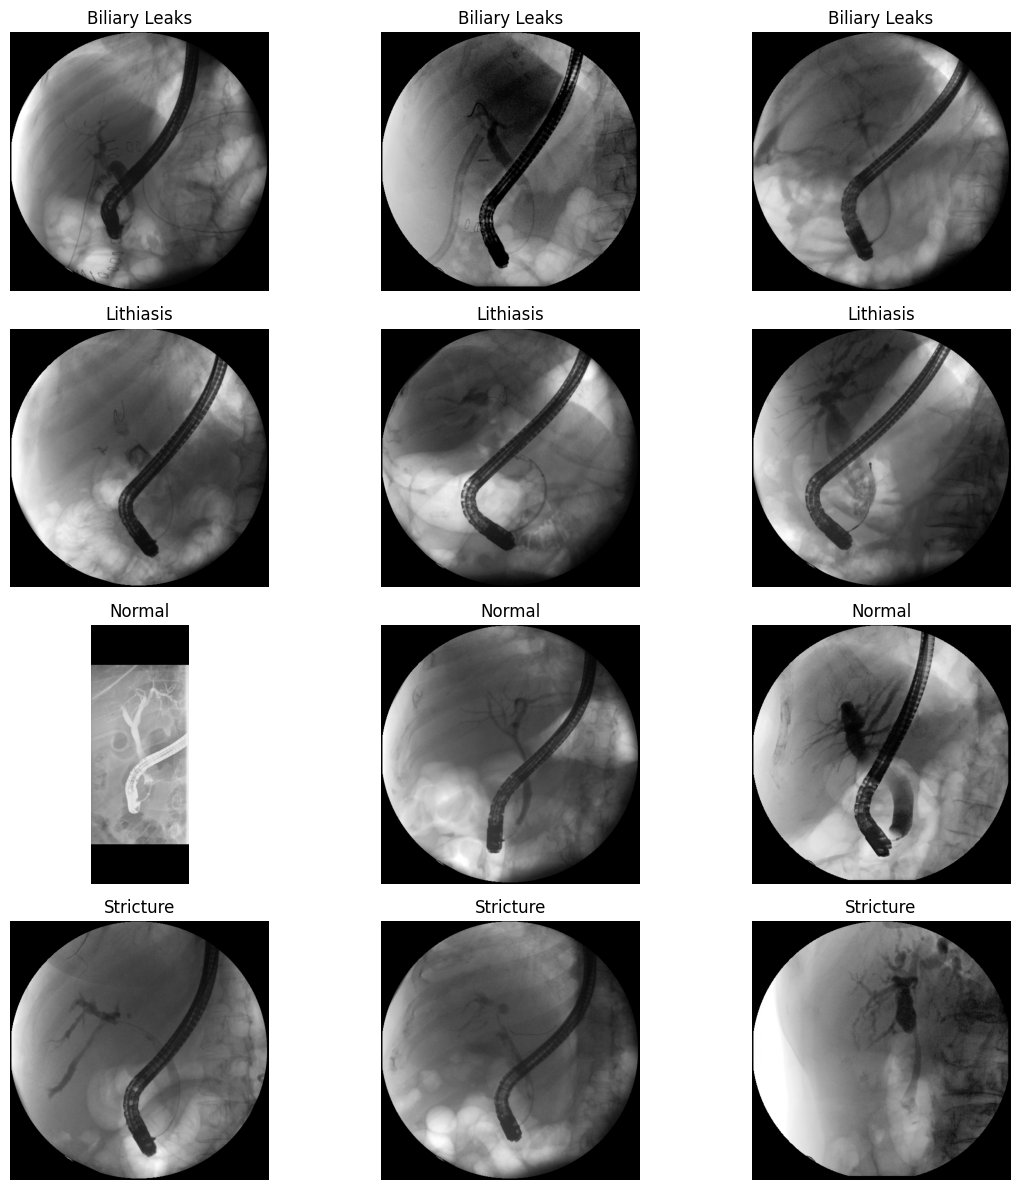

In [5]:
# Visualizar algumas imagens por classe

def show_examples_per_class(dataframe, n_per_class=3):
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(4*n_per_class, 3*n_classes))
    if n_classes == 1:
        axes = np.expand_dims(axes, 0)
    for row_idx, class_name in enumerate(class_names):
        subset = dataframe[dataframe['final_label'] == class_name].sample(
            n=min(n_per_class, (dataframe['final_label'] == class_name).sum()),
            random_state=SEED
        )
        for col_idx in range(n_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis('off')
            if col_idx < len(subset):
                img = Image.open(subset.iloc[col_idx]['image_path']).convert('RGB')
                ax.imshow(img, cmap='gray')
                ax.set_title(class_name)
    plt.tight_layout()
    plt.show()

show_examples_per_class(filtered, n_per_class=3)

## 3. Split treino / validação / teste por paciente

O split é feito por `patient_id`, evitando que imagens do mesmo paciente apareçam simultaneamente em treino e teste. Isto é importante para uma avaliação mais realista.

In [6]:
# =========================
# 3. Split por patient_id
# =========================

if 'patient_id' not in filtered.columns:
    raise ValueError('A coluna patient_id não existe no metadata. O split por paciente é necessário para evitar fuga de informação.')

patient_summary = (
    filtered
    .groupby('patient_id')
    .agg(patient_label=('final_label', lambda x: x.mode().iloc[0]), n_images=('final_label', 'size'))
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label']
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label']
)

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy().reset_index(drop=True)
val_df = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy().reset_index(drop=True)
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy().reset_index(drop=True)

print('Split sizes:')
print('train:', len(train_df), '| patients:', train_df['patient_id'].nunique())
print('val:  ', len(val_df), '| patients:', val_df['patient_id'].nunique())
print('test: ', len(test_df), '| patients:', test_df['patient_id'].nunique())

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{split_name} label distribution:')
    display(split_df['final_label'].value_counts().reindex(class_names))

# Guardar os splits para reprodutibilidade
train_df.to_csv(os.path.join(RESULTS_DIR, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(RESULTS_DIR, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(RESULTS_DIR, 'test_split.csv'), index=False)

Split sizes:
train: 1001 | patients: 305
val:   313 | patients: 65
test:  254 | patients: 66

train label distribution:


final_label
Biliary Leaks     78
Lithiasis        468
Normal           206
Stricture        249
Name: count, dtype: int64


val label distribution:


final_label
Biliary Leaks     55
Lithiasis        142
Normal            58
Stricture         58
Name: count, dtype: int64


test label distribution:


final_label
Biliary Leaks     18
Lithiasis        116
Normal            35
Stricture         85
Name: count, dtype: int64

## 4. Pré-processamento e DataLoaders

Foram incluídas duas opções de geometria:

- `direct_resize`: redimensiona diretamente para `IMG_SIZE x IMG_SIZE`;
- `pad_resize_if_rect`: primeiro aplica padding para tornar a imagem quadrada e só depois redimensiona. Esta opção preserva melhor a geometria de imagens retangulares.

Também existe opção de ativar `CLAHE`, útil para melhorar contraste em imagens fluoroscópicas.

In [7]:
# =========================
# 4. Pré-processamento
# =========================

def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas


def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)


def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=False) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    elif geometry_mode == 'direct_resize':
        pass
    else:
        raise ValueError(f'Unknown geometry_mode: {geometry_mode}')
    image = image.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    return image


class ERCPDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Callable, geometry_mode='pad_resize_if_rect', use_clahe=False, return_metadata=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.geometry_mode = geometry_mode
        self.use_clahe = use_clahe
        self.return_metadata = return_metadata

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        image_tensor = self.transform(image)
        target = int(row['target'])
        if self.return_metadata:
            return image_tensor, target, row['image_path']
        return image_tensor, target

In [8]:
# Transformações
# Nota: MobileNetV3 usa ImageNet normalization. Augmentations moderadas para não destruir informação clínica.

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.12, contrast=0.18),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ERCPDataset(train_df, train_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
val_ds = ERCPDataset(val_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds = ERCPDataset(test_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds_with_paths = ERCPDataset(test_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE, return_metadata=True)

class_counts = train_df['target'].value_counts().sort_index().reindex(range(len(class_names)), fill_value=0)
class_weights_np = len(train_df) / (len(class_names) * np.maximum(class_counts.values, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

print('Class counts:', dict(zip(class_names, class_counts.values)))
print('Class weights:', dict(zip(class_names, class_weights_np.round(3))))

if USE_WEIGHTED_SAMPLER:
    weight_lookup = {i: float(w) for i, w in enumerate(class_weights_np)}
    sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
    train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    shuffle_train = False
else:
    train_sampler = None
    shuffle_train = True

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=shuffle_train,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader_with_paths = DataLoader(
    test_ds_with_paths,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

Class counts: {'Biliary Leaks': np.int64(78), 'Lithiasis': np.int64(468), 'Normal': np.int64(206), 'Stricture': np.int64(249)}
Class weights: {'Biliary Leaks': np.float64(3.208), 'Lithiasis': np.float64(0.535), 'Normal': np.float64(1.215), 'Stricture': np.float64(1.005)}


## 5. Modelo: MobileNetV3-Large

A MobileNetV3-Large é uma CNN leve, desenhada para ser eficiente. Neste trabalho é interessante porque permite comparar uma arquitetura mais pequena com modelos mais pesados, como EfficientNet.

Estratégia usada:

1. carregar pesos pré-treinados em ImageNet;
2. substituir a cabeça final por uma camada com 4 saídas;
3. treinar primeiro apenas a cabeça;
4. depois fazer *fine-tuning parcial* dos últimos blocos convolucionais.

In [9]:
# =========================
# 5. Modelo e loss
# =========================

class FocalLossMulticlass(nn.Module):
    """Focal Loss multi-classe com suporte para class weights."""
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss


def build_mobilenet_v3_large(num_classes: int, pretrained: bool = True) -> nn.Module:
    if MobileNet_V3_Large_Weights is not None:
        weights = MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        model = mobilenet_v3_large(weights=weights)
    else:
        model = mobilenet_v3_large(pretrained=pretrained)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def set_backbone_trainable(model: nn.Module, trainable: bool):
    for param in model.features.parameters():
        param.requires_grad = trainable


def unfreeze_last_feature_blocks(model: nn.Module, n_blocks: int):
    # Congelar tudo primeiro
    for param in model.features.parameters():
        param.requires_grad = False
    # Desbloquear os últimos n blocos
    for block in model.features[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    # Classifier fica sempre treinável
    for param in model.classifier.parameters():
        param.requires_grad = True


def count_trainable_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def get_criterion():
    if USE_FOCAL_LOSS:
        return FocalLossMulticlass(alpha=class_weights, gamma=FOCAL_GAMMA)
    return nn.CrossEntropyLoss(weight=class_weights)

model = build_mobilenet_v3_large(len(class_names), pretrained=USE_PRETRAINED).to(device)

if FREEZE_BACKBONE_HEAD_PHASE:
    set_backbone_trainable(model, trainable=False)

for param in model.classifier.parameters():
    param.requires_grad = True

total_params, trainable_params = count_trainable_params(model)
print(model)
print(f'Total params: {total_params:,}')
print(f'Trainable params initial phase: {trainable_params:,}')

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [10]:
# Funções de métricas e avaliação

def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs

## 6. Treino

O treino é dividido em duas fases:

- **Fase 1 — head training:** congela o extrator de características e treina só o classificador;
- **Fase 2 — fine-tuning parcial:** descongela os últimos blocos da MobileNetV3 e continua o treino com uma learning rate menor.

O melhor modelo é escolhido pelo **F1-score macro na validação**, porque esta métrica é mais adequada para datasets desbalanceados.

In [11]:
# =========================
# 6. Treino
# =========================

CHECKPOINT_PATH = os.path.join(MODELS_DIR, 'best_mobilenet_v3_large.pth')
HISTORY_PATH = os.path.join(RESULTS_DIR, 'training_history_mobilenet_v3_large.csv')


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    all_targets, all_preds = [], []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        probs = torch.softmax(outputs.detach(), dim=1)
        preds = torch.argmax(probs, dim=1)
        running_loss += loss.item() * images.size(0)
        all_targets.extend(targets.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    train_loss = running_loss / len(loader.dataset)
    train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return train_loss, train_f1


def run_training():
    model = build_mobilenet_v3_large(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = get_criterion()
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    global_epoch = 0

    phases = [
        ('head', NUM_EPOCHS_HEAD, LR_HEAD),
        ('finetune', NUM_EPOCHS_FINETUNE, LR_FINETUNE),
    ]

    for phase_name, n_epochs, lr in phases:
        if phase_name == 'head':
            if FREEZE_BACKBONE_HEAD_PHASE:
                set_backbone_trainable(model, trainable=False)
            for param in model.classifier.parameters():
                param.requires_grad = True
        else:
            unfreeze_last_feature_blocks(model, UNFREEZE_LAST_N_FEATURE_BLOCKS)

        total_params, trainable_params = count_trainable_params(model)
        print(f'\nPhase: {phase_name} | trainable params: {trainable_params:,}/{total_params:,}')

        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(n_epochs, 1))

        for epoch in range(n_epochs):
            global_epoch += 1
            train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
            val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
            val_f1 = val_metrics['macro_f1']
            current_lr = optimizer.param_groups[0]['lr']

            history.append({
                'epoch': global_epoch,
                'phase': phase_name,
                'lr': current_lr,
                'train_loss': train_loss,
                'train_macro_f1': train_f1,
                'val_loss': val_metrics['loss'],
                'val_macro_f1': val_f1,
                'val_accuracy': val_metrics['accuracy'],
                'val_balanced_accuracy': val_metrics['balanced_accuracy'],
                'val_macro_precision': val_metrics['macro_precision'],
                'val_macro_recall': val_metrics['macro_recall'],
                'val_auc': val_metrics['roc_auc_ovo_macro'],
                'val_pr_auc': val_metrics['pr_auc_macro'],
            })

            scheduler.step()

            print(
                f"Epoch {global_epoch:02d} [{phase_name}] | "
                f"train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | "
                f"val_loss {val_metrics['loss']:.4f} | val_f1 {val_f1:.4f}"
            )

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_epoch = global_epoch
                best_state = copy.deepcopy(model.state_dict())
                torch.save(best_state, CHECKPOINT_PATH)
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= PATIENCE:
                print('Early stopping triggered')
                model.load_state_dict(best_state)
                history_df = pd.DataFrame(history)
                history_df.to_csv(HISTORY_PATH, index=False)
                return model, history_df, best_epoch, best_val_f1

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(HISTORY_PATH, index=False)
    return model, history_df, best_epoch, best_val_f1

# Executar treino
model, history_df, best_epoch, best_val_f1 = run_training()
print('\nBest epoch:', best_epoch)
print('Best val macro F1:', best_val_f1)


Phase: head | trainable params: 1,235,204/4,207,156
Epoch 01 [head] | train_loss 1.1494 | train_f1 0.1680 | val_loss 1.0275 | val_f1 0.0898
Epoch 02 [head] | train_loss 0.9008 | train_f1 0.2705 | val_loss 1.1910 | val_f1 0.0728
Epoch 03 [head] | train_loss 0.8339 | train_f1 0.3192 | val_loss 1.1716 | val_f1 0.1285
Epoch 04 [head] | train_loss 0.7751 | train_f1 0.3522 | val_loss 1.1063 | val_f1 0.1520
Epoch 05 [head] | train_loss 0.7215 | train_f1 0.3513 | val_loss 1.0862 | val_f1 0.1869

Phase: finetune | trainable params: 3,414,668/4,207,156
Epoch 06 [finetune] | train_loss 0.5597 | train_f1 0.4620 | val_loss 1.1595 | val_f1 0.2256
Epoch 07 [finetune] | train_loss 0.4218 | train_f1 0.5354 | val_loss 1.0946 | val_f1 0.2039
Epoch 08 [finetune] | train_loss 0.3282 | train_f1 0.5830 | val_loss 1.2710 | val_f1 0.2633
Epoch 09 [finetune] | train_loss 0.2871 | train_f1 0.6102 | val_loss 1.3163 | val_f1 0.3024
Epoch 10 [finetune] | train_loss 0.2196 | train_f1 0.6734 | val_loss 1.7497 | val_

## 7. Curvas de treino

,epoch,phase,lr,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_macro_precision,val_macro_recall,val_auc,val_pr_auc
22,23,finetune,0.000023,0.095586,0.798708,1.854449,0.398291,0.421725,0.453792,0.470614,0.453792,0.766626,0.523397
23,24,finetune,0.000018,0.081973,0.845175,1.774215,0.423673,0.444089,0.471685,0.472712,0.471685,0.768464,0.523526
24,25,finetune,0.000014,0.058587,0.842859,1.660468,0.418493,0.440895,0.457176,0.459802,0.457176,0.769151,0.528968
25,26,finetune,0.000010,0.074978,0.841687,1.614082,0.439418,0.453674,0.474887,0.482708,0.474887,0.767480,0.527728
26,27,finetune,0.000006,0.074366,0.821708,1.609331,0.433115,0.447284,0.471366,0.468950,0.471366,0.765689,0.523089


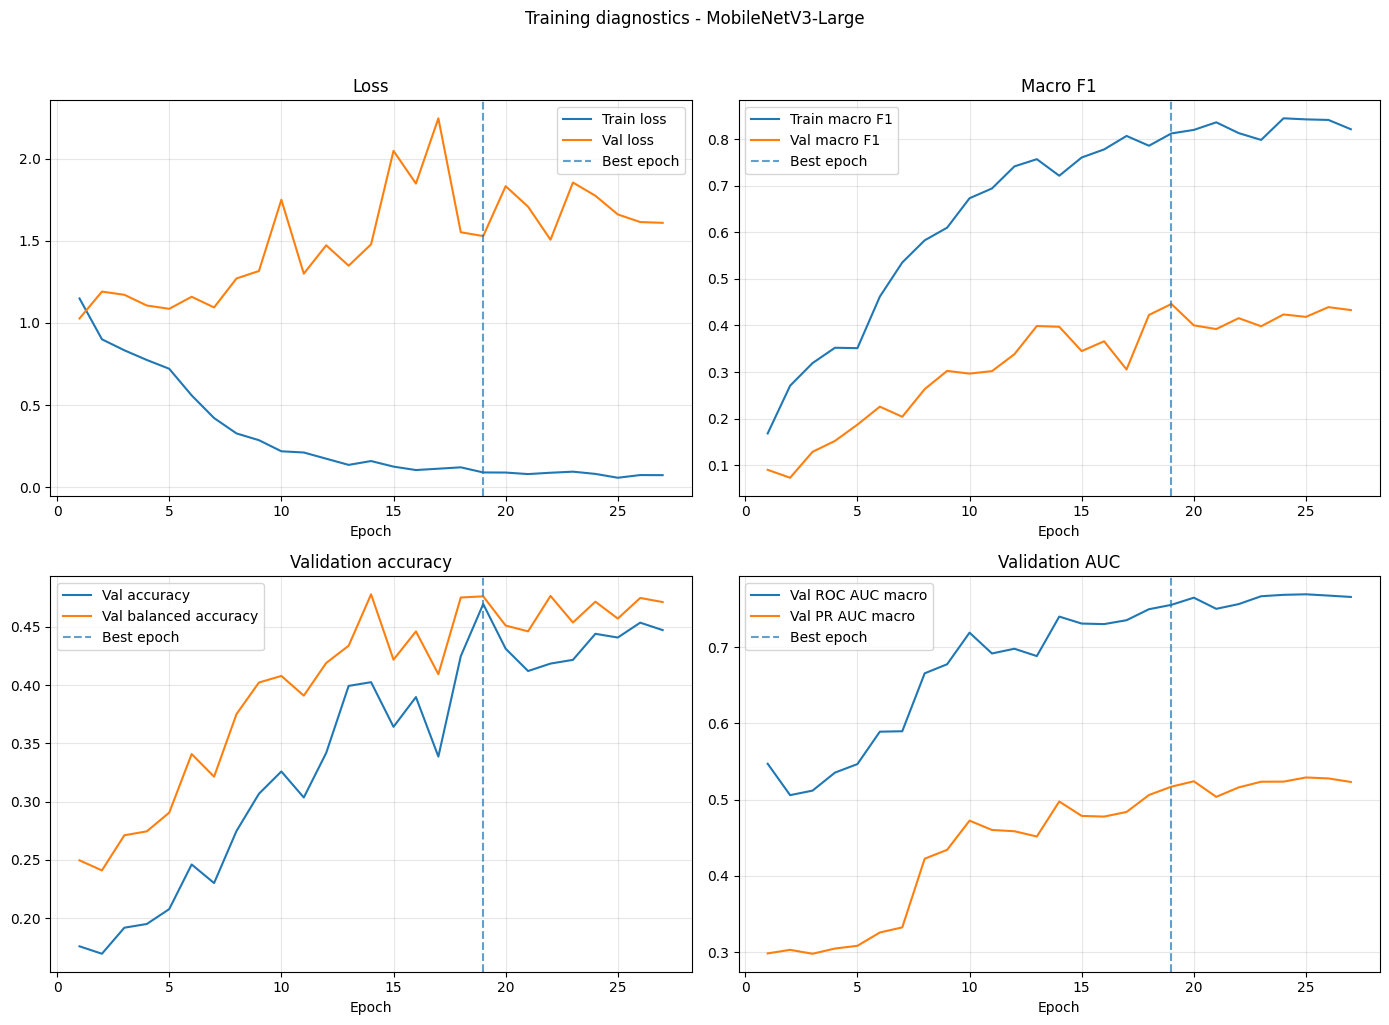

In [12]:
# Carregar histórico se necessário
if 'history_df' not in globals() or history_df is None or history_df.empty:
    history_df = pd.read_csv(HISTORY_PATH)
    best_epoch = int(history_df.loc[history_df['val_macro_f1'].idxmax(), 'epoch'])
    best_val_f1 = float(history_df['val_macro_f1'].max())

history_df = history_df.sort_values('epoch').reset_index(drop=True)
display(history_df.tail())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val loss')
axes[0].axvline(best_epoch, linestyle='--', alpha=0.7, label='Best epoch')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df['epoch'], history_df['train_macro_f1'], label='Train macro F1')
axes[1].plot(history_df['epoch'], history_df['val_macro_f1'], label='Val macro F1')
axes[1].axvline(best_epoch, linestyle='--', alpha=0.7, label='Best epoch')
axes[1].set_title('Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history_df['epoch'], history_df['val_accuracy'], label='Val accuracy')
axes[2].plot(history_df['epoch'], history_df['val_balanced_accuracy'], label='Val balanced accuracy')
axes[2].axvline(best_epoch, linestyle='--', alpha=0.7, label='Best epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(history_df['epoch'], history_df['val_auc'], label='Val ROC AUC macro')
axes[3].plot(history_df['epoch'], history_df['val_pr_auc'], label='Val PR AUC macro')
axes[3].axvline(best_epoch, linestyle='--', alpha=0.7, label='Best epoch')
axes[3].set_title('Validation AUC')
axes[3].set_xlabel('Epoch')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.suptitle('Training diagnostics - MobileNetV3-Large', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics_mobilenet_v3_large.png'), dpi=200, bbox_inches='tight')
plt.show()

## 8. Avaliação no conjunto de teste

Nesta secção são calculadas as métricas finais no conjunto de teste, incluindo o **F1-score macro**, que é a métrica principal para comparação com a baseline.

In [13]:
# =========================
# 8. Avaliação final
# =========================

# Carregar melhor checkpoint, se necessário
if 'model' not in globals() or model is None:
    model = build_mobilenet_v3_large(len(class_names), pretrained=False).to(device)

if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

criterion = get_criterion()
test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

print('Test metrics:')
for k, v in test_metrics.items():
    print(f'{k}: {v:.4f}' if isinstance(v, (float, np.floating)) else f'{k}: {v}')

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
display(report_df)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
display(cm_df)

# Guardar resultados
with open(os.path.join(RESULTS_DIR, 'classification_report_mobilenet_v3_large.json'), 'w') as f:
    json.dump(report, f, indent=2)

report_df.to_csv(os.path.join(RESULTS_DIR, 'classification_report_mobilenet_v3_large.csv'))
cm_df.to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix_mobilenet_v3_large.csv'))

summary = pd.DataFrame([{
    'model': 'mobilenet_v3_large',
    'img_size': IMG_SIZE,
    'geometry_mode': GEOMETRY_MODE,
    'use_clahe': USE_CLAHE,
    'use_focal_loss': USE_FOCAL_LOSS,
    'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'best_epoch': best_epoch if 'best_epoch' in globals() else np.nan,
    'best_val_macro_f1': best_val_f1 if 'best_val_f1' in globals() else np.nan,
    **{f'test_{k}': v for k, v in test_metrics.items()}
}])
summary.to_csv(os.path.join(RESULTS_DIR, 'test_summary_mobilenet_v3_large.csv'), index=False)
display(summary)

Test metrics:
accuracy: 0.4567
balanced_accuracy: 0.4407
macro_f1: 0.4013
macro_precision: 0.4106
macro_recall: 0.4407
roc_auc_ovo_macro: 0.6857
pr_auc_macro: 0.4308
loss: 1.2966


,precision,recall,f1-score,support
Biliary Leaks,0.190476,0.222222,0.205128,18.000000
Lithiasis,0.619048,0.448276,0.520000,116.000000
Normal,0.280488,0.657143,0.393162,35.000000
Stricture,0.552239,0.435294,0.486842,85.000000
accuracy,0.456693,0.456693,0.456693,0.456693
macro avg,0.410563,0.440734,0.401283,254.000000
weighted avg,0.519667,0.456693,0.469112,254.000000


,Biliary Leaks,Lithiasis,Normal,Stricture
Biliary Leaks,4,4,7,3
Lithiasis,2,52,38,24
Normal,5,4,23,3
Stricture,10,24,14,37


,model,img_size,geometry_mode,use_clahe,use_focal_loss,use_weighted_sampler,best_epoch,best_val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_roc_auc_ovo_macro,test_pr_auc_macro,test_loss
0,mobilenet_v3_large,224,pad_resize_if_rect,False,True,True,19,0.446153,0.456693,0.440734,0.401283,0.410563,0.440734,0.685717,0.430761,1.296645


In [ ]:
# Matriz de confusão

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix - MobileNetV3-Large')
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')

threshold = cm.max() / 2 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_mobilenet_v3_large.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Curvas ROC e Precision-Recall por classe

y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC
for idx, class_name in enumerate(class_names):
    try:
        fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_prob[:, idx])
        roc_auc_value = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc_value:.3f})')
    except Exception:
        pass

try:
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    axes[0].plot(fpr_micro, tpr_micro, label=f'Micro-average (AUC={roc_auc_micro:.3f})', linewidth=2.5)
except Exception:
    pass

axes[0].plot([0, 1], [0, 1], linestyle='--', alpha=0.5)
axes[0].set_title('Test ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Precision-Recall
for idx, class_name in enumerate(class_names):
    try:
        precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_prob[:, idx])
        pr_auc_value = auc(recall, precision)
        axes[1].plot(recall, precision, label=f'{class_name} (AUC={pr_auc_value:.3f})')
    except Exception:
        pass

try:
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    pr_auc_micro = auc(recall_micro, precision_micro)
    axes[1].plot(recall_micro, precision_micro, label=f'Micro-average (AUC={pr_auc_micro:.3f})', linewidth=2.5)
except Exception:
    pass

axes[1].set_title('Test Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_pr_curves_mobilenet_v3_large.png'), dpi=200, bbox_inches='tight')
plt.show()

## 9. Análise de erros

Esta tabela ajuda a perceber onde a MobileNet está a falhar: mostra exemplos em que a classe verdadeira é diferente da classe prevista, juntamente com a probabilidade atribuída pelo modelo.

In [ ]:
# Criar tabela de previsões no teste
pred_df = test_df.copy().reset_index(drop=True)
pred_df['true_label'] = [idx_to_class[int(i)] for i in y_true]
pred_df['pred_label'] = [idx_to_class[int(i)] for i in y_pred]
pred_df['pred_confidence'] = y_prob.max(axis=1)
for idx, class_name in enumerate(class_names):
    pred_df[f'prob_{class_name}'] = y_prob[:, idx]

pred_df.to_csv(os.path.join(RESULTS_DIR, 'test_predictions_mobilenet_v3_large.csv'), index=False)

errors_df = pred_df[pred_df['true_label'] != pred_df['pred_label']].sort_values('pred_confidence', ascending=False)
print('N.º de erros no teste:', len(errors_df), '/', len(pred_df))
display(errors_df[['image_path', 'true_label', 'pred_label', 'pred_confidence'] + [f'prob_{c}' for c in class_names]].head(20))

In [ ]:
# Visualizar alguns erros

def show_prediction_examples(dataframe, max_examples=8, title='Examples'):
    if len(dataframe) == 0:
        print('Sem exemplos para mostrar.')
        return
    subset = dataframe.head(max_examples)
    n = len(subset)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img, cmap='gray')
        ax.set_title(f"T: {row['true_label']}\nP: {row['pred_label']} ({row['pred_confidence']:.2f})")
        ax.axis('off')
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

show_prediction_examples(errors_df, max_examples=8, title='Erros com maior confiança')

## 10. Grad-CAM

A Grad-CAM é obrigatória no trabalho e permite visualizar as zonas da imagem que mais influenciaram a decisão do modelo.

Na MobileNetV3, a camada alvo usada é o último bloco convolucional de `model.features`.

In [ ]:
# =========================
# 10. Grad-CAM
# =========================

class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor: torch.Tensor, target_class: Optional[int] = None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        output = self.model(input_tensor)
        if target_class is None:
            target_class = int(output.argmax(dim=1).item())

        score = output[:, target_class].sum()
        score.backward(retain_graph=True)

        gradients = self.gradients
        activations = self.activations
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, output.detach()

    def close(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def denormalize_tensor(img_tensor: torch.Tensor):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def overlay_cam(image_np, cam, alpha=0.45):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = (1 - alpha) * image_np + alpha * heatmap
    return np.clip(overlay, 0, 1)


def plot_gradcam_examples(model, loader_with_paths, max_examples=8, only_errors=False):
    target_layer = model.features[-1]
    gradcam = GradCAM(model, target_layer)
    shown = 0
    rows = []

    for image_tensor, target, path in loader_with_paths:
        image_tensor = image_tensor.to(device)
        target_int = int(target.item())

        cam, output = gradcam(image_tensor, target_class=None)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred_int = int(np.argmax(probs))

        if only_errors and pred_int == target_int:
            continue

        image_np = denormalize_tensor(image_tensor[0])
        overlay = overlay_cam(image_np, cam)
        rows.append((image_np, overlay, target_int, pred_int, probs[pred_int], path[0]))
        shown += 1
        if shown >= max_examples:
            break

    gradcam.close()

    if len(rows) == 0:
        print('Sem exemplos para mostrar.')
        return

    fig, axes = plt.subplots(len(rows), 2, figsize=(8, 4 * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, 0)

    for i, (image_np, overlay, target_int, pred_int, conf, path) in enumerate(rows):
        axes[i, 0].imshow(image_np)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'Original\nTrue: {idx_to_class[target_int]}')

        axes[i, 1].imshow(overlay)
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f'Grad-CAM\nPred: {idx_to_class[pred_int]} ({conf:.2f})')

    plt.tight_layout()
    suffix = 'errors' if only_errors else 'examples'
    out_path = os.path.join(RESULTS_DIR, f'gradcam_mobilenet_v3_large_{suffix}.png')
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Grad-CAM saved at:', out_path)

In [ ]:
# Grad-CAM em exemplos do teste
plot_gradcam_examples(model, test_loader_with_paths, max_examples=6, only_errors=False)

In [ ]:
# Grad-CAM apenas em erros, se existirem
plot_gradcam_examples(model, test_loader_with_paths, max_examples=6, only_errors=True)

## 11. Conclusão automática para relatório

Esta célula gera um pequeno resumo dos resultados para facilitar a escrita do relatório técnico.

In [ ]:
# Texto-resumo para o relatório

macro_f1 = test_metrics['macro_f1']
bal_acc = test_metrics['balanced_accuracy']
auc_macro = test_metrics.get('roc_auc_ovo_macro', np.nan)

summary_text = f"""
MobileNetV3-Large foi avaliada como uma arquitetura leve baseada em transfer learning. 
O pré-processamento utilizou o modo {GEOMETRY_MODE}, com IMG_SIZE={IMG_SIZE}, CLAHE={USE_CLAHE}, 
e normalização ImageNet. Para mitigar o desequilíbrio das classes foram usados 
WeightedRandomSampler={USE_WEIGHTED_SAMPLER} e Focal Loss={USE_FOCAL_LOSS}. 
O melhor modelo foi selecionado pelo F1-score macro na validação, tendo ocorrido na época {best_epoch}. 
No conjunto de teste, o modelo obteve F1-score macro de {macro_f1:.4f}, balanced accuracy de {bal_acc:.4f} 
e ROC-AUC macro de {auc_macro:.4f}. Estes resultados devem ser comparados com a baseline do artigo, 
com especial atenção ao desempenho por classe e aos erros em classes clínicas mais críticas.
""".strip()

print(summary_text)

with open(os.path.join(RESULTS_DIR, 'report_summary_mobilenet_v3_large.txt'), 'w', encoding='utf-8') as f:
    f.write(summary_text)